In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve
)

In [2]:
telemetry = pd.read_csv("C:/Users/infantshubiksha.john/OneDrive - Everrenew Energy Private Limited/Documents/Necter_assesment/telemetry.csv")

telemetry.head()

,timestamp,site_id,building_id,asset_id,temperature,humidity,pressure,vibration,power_consumption,occupancy_count,operating_mode,fault_flag
0,2025-01-01 00:00:00,S1,B1,B1_CH_01,15.12,66.41,101.40,0.65,29.42,4,Cooling,0
1,2025-01-01 01:00:00,S1,B1,B1_CH_01,18.19,62.37,100.86,0.89,31.46,10,Cooling,0
2,2025-01-01 02:00:00,S1,B1,B1_CH_01,20.17,61.50,101.61,0.32,27.67,8,Idle,0
3,2025-01-01 03:00:00,S1,B1,B1_CH_01,20.87,38.54,101.56,0.89,27.35,11,Idle,0
4,2025-01-01 04:00:00,S1,B1,B1_CH_01,17.63,56.71,101.79,1.27,28.42,0,Idle,0


In [58]:
#convert timestamp
telemetry["timestamp"] = pd.to_datetime(telemetry["timestamp"])

# Sort by asset and time
telemetry = telemetry.sort_values(
    ["asset_id", "timestamp"]
).reset_index(drop=True)

print(telemetry[[
    "asset_id",
    "timestamp",
    "fault_flag"
]].head(10))

    asset_id           timestamp  fault_flag
0  B1_AHU_01 2025-01-01 01:00:00           0
1  B1_AHU_01 2025-01-01 02:00:00           0
2  B1_AHU_01 2025-01-01 03:00:00           0
3  B1_AHU_01 2025-01-01 04:00:00           0
4  B1_AHU_01 2025-01-01 05:00:00           0
5  B1_AHU_01 2025-01-01 06:00:00           0
6  B1_AHU_01 2025-01-01 07:00:00           0
7  B1_AHU_01 2025-01-01 08:00:00           0
8  B1_AHU_01 2025-01-01 09:00:00           0
9  B1_AHU_01 2025-01-01 10:00:00           0


In [59]:
#check the time interval
time_diff = (
    telemetry
    .groupby("asset_id")["timestamp"]
    .diff()
)

print("Time intervals:")
print(time_diff.value_counts().head(10))

Time intervals:
timestamp
0 days 01:00:00    59388
Name: count, dtype: int64


In [62]:
#future fault target
telemetry["future_fault"] = (
    telemetry
    .groupby("asset_id")["fault_flag"]
    .transform(
        lambda x: (
            x.shift(-1)
             .rolling(window=24, min_periods=1)
             .max()
        )
    )
)

In [63]:
#check the target
print("Future fault distribution:")
print(telemetry["future_fault"].value_counts(dropna=False))

print("\nFuture fault percentage:")
print(
    telemetry["future_fault"]
    .value_counts(normalize=True, dropna=False) * 100
)

Future fault distribution:
future_fault
0.0    43364
1.0    16066
Name: count, dtype: int64

Future fault percentage:
future_fault
0.0    72.966515
1.0    27.033485
Name: proportion, dtype: float64


In [64]:
#target
print(
    telemetry[
        [
            "asset_id",
            "timestamp",
            "fault_flag",
            "future_fault"
        ]
    ].head(30)
)

     asset_id           timestamp  fault_flag  future_fault
0   B1_AHU_01 2025-01-01 01:00:00           0           0.0
1   B1_AHU_01 2025-01-01 02:00:00           0           0.0
2   B1_AHU_01 2025-01-01 03:00:00           0           0.0
3   B1_AHU_01 2025-01-01 04:00:00           0           0.0
4   B1_AHU_01 2025-01-01 05:00:00           0           0.0
5   B1_AHU_01 2025-01-01 06:00:00           0           0.0
6   B1_AHU_01 2025-01-01 07:00:00           0           0.0
7   B1_AHU_01 2025-01-01 08:00:00           0           0.0
8   B1_AHU_01 2025-01-01 09:00:00           0           0.0
9   B1_AHU_01 2025-01-01 10:00:00           0           0.0
10  B1_AHU_01 2025-01-01 11:00:00           0           0.0
11  B1_AHU_01 2025-01-01 12:00:00           0           0.0
12  B1_AHU_01 2025-01-01 13:00:00           0           0.0
13  B1_AHU_01 2025-01-01 14:00:00           0           0.0
14  B1_AHU_01 2025-01-01 15:00:00           0           0.0
15  B1_AHU_01 2025-01-01 16:00:00       

In [65]:
#remove rows
telemetry = telemetry.dropna(
    subset=["future_fault"]
).copy()

telemetry["future_fault"] = telemetry[
    "future_fault"
].astype(int)

In [66]:
#create x and y 
features = [
    "temperature",
    "humidity",
    "pressure",
    "vibration",
    "power_consumption",
    "occupancy_count",
    "temp_rolling_24h",
    "vibration_rolling_24h",
    "power_rolling_24h",
    "temp_lag1",
    "vibration_lag1",
    "power_lag1"
]

X = telemetry[features]

y = telemetry["future_fault"]

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\ny distribution:")
print(y.value_counts())

X shape: (59430, 12)
y shape: (59430,)

y distribution:
future_fault
0    43364
1    16066
Name: count, dtype: int64


In [67]:
#train test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

print("\ny_train:")
print(y_train.value_counts())

print("\ny_test:")
print(y_test.value_counts())

X_train: (47544, 12)
X_test : (11886, 12)

y_train:
future_fault
0    34691
1    12853
Name: count, dtype: int64

y_test:
future_fault
0    8673
1    3213
Name: count, dtype: int64


In [68]:
#train random forest
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_fe

In [69]:
#prediction
y_pred = model.predict(X_test)

y_prob = model.predict_proba(X_test)[:, 1]

In [70]:
#evaluating the model
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        zero_division=0
    )
)

print("\nMetrics:")
print("Accuracy :", round(accuracy_score(y_test, y_pred), 4))
print("Precision:", round(precision_score(y_test, y_pred, zero_division=0), 4))
print("Recall   :", round(recall_score(y_test, y_pred, zero_division=0), 4))
print("F1 Score :", round(f1_score(y_test, y_pred, zero_division=0), 4))
print("ROC-AUC  :", round(roc_auc_score(y_test, y_prob), 4))

Confusion Matrix:
[[7872  801]
 [2439  774]]

Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.91      0.83      8673
           1       0.49      0.24      0.32      3213

    accuracy                           0.73     11886
   macro avg       0.63      0.57      0.58     11886
weighted avg       0.69      0.73      0.69     11886


Metrics:
Accuracy : 0.7274
Precision: 0.4914
Recall   : 0.2409
F1 Score : 0.3233
ROC-AUC  : 0.672


In [71]:
#test different threshold
thresholds = [0.50, 0.45, 0.40, 0.35, 0.30, 0.25, 0.20]

results = []

for threshold in thresholds:

    y_pred_threshold = (
        y_prob >= threshold
    ).astype(int)

    results.append({
        "Threshold": threshold,
        "Precision": precision_score(
            y_test,
            y_pred_threshold,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test,
            y_pred_threshold,
            zero_division=0
        ),
        "F1 Score": f1_score(
            y_test,
            y_pred_threshold,
            zero_division=0
        ),
        "Accuracy": accuracy_score(
            y_test,
            y_pred_threshold
        )
    })

threshold_results = pd.DataFrame(results)

print(threshold_results)

   Threshold  Precision    Recall  F1 Score  Accuracy
0       0.50   0.487834  0.255836  0.335647  0.726233
1       0.45   0.435149  0.417678  0.426235  0.696029
2       0.40   0.386368  0.591036  0.467274  0.635706
3       0.35   0.348254  0.760349  0.477708  0.550564
4       0.30   0.317423  0.875506  0.465921  0.457429
5       0.25   0.296332  0.945534  0.451244  0.378344
6       0.20   0.283229  0.982882  0.439741  0.322985


In [72]:
#threshlod to 0.35
best_threshold = 0.35

y_pred_final = (
    y_prob >= best_threshold
).astype(int)

In [73]:
#final classification report
target = "future_fault"
print("Final Classification Report:")
print(
    classification_report(
        y_test,
        y_pred_final,
        zero_division=0
    )
)

Final Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.47      0.61      8673
           1       0.35      0.76      0.48      3213

    accuracy                           0.55     11886
   macro avg       0.60      0.62      0.54     11886
weighted avg       0.71      0.55      0.57     11886



In [74]:
#confusuion matrix
print("Final Confusion Matrix:")
print(
    confusion_matrix(
        y_test,
        y_pred_final
    )
)

Final Confusion Matrix:
[[4101 4572]
 [ 770 2443]]


In [75]:
#final metrics
final_accuracy = accuracy_score(
    y_test,
    y_pred_final
)

final_precision = precision_score(
    y_test,
    y_pred_final,
    zero_division=0
)

final_recall = recall_score(
    y_test,
    y_pred_final,
    zero_division=0
)

final_f1 = f1_score(
    y_test,
    y_pred_final,
    zero_division=0
)

print("Final Accuracy :", round(final_accuracy, 4))
print("Final Precision:", round(final_precision, 4))
print("Final Recall   :", round(final_recall, 4))
print("Final F1 Score :", round(final_f1, 4))
print("ROC-AUC        :", round(roc_auc_score(y_test, y_prob), 4))

Final Accuracy : 0.5506
Final Precision: 0.3483
Final Recall   : 0.7603
Final F1 Score : 0.4777
ROC-AUC        : 0.672


In [76]:
#failures
actual_failures = (y_test == 1).sum()

detected_failures = (
    (y_test == 1) &
    (y_pred_final == 1)
).sum()

missed_failures = (
    (y_test == 1) &
    (y_pred_final == 0)
).sum()

false_alarms = (
    (y_test == 0) &
    (y_pred_final == 1)
).sum()

print("Actual failures   :", actual_failures)
print("Detected failures :", detected_failures)
print("Missed failures   :", missed_failures)
print("False alarms      :", false_alarms)

Actual failures   : 3213
Detected failures : 2443
Missed failures   : 770
False alarms      : 4572


In [77]:
#feature importance
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance)

                  Feature  Importance
6        temp_rolling_24h    0.106256
8       power_rolling_24h    0.105541
7   vibration_rolling_24h    0.098163
9               temp_lag1    0.080639
0             temperature    0.080630
11             power_lag1    0.079806
4       power_consumption    0.079398
1                humidity    0.078038
2                pressure    0.077719
10         vibration_lag1    0.075308
3               vibration    0.074841
5         occupancy_count    0.063661


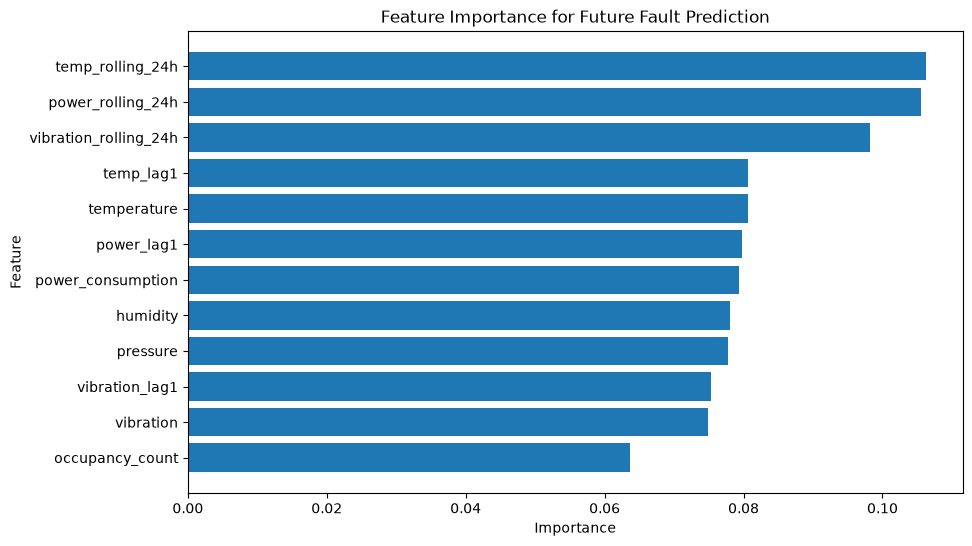

In [78]:
#plot feature importance
import matplotlib.pyplot as plt

top_features = feature_importance.head(12)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Feature Importance for Future Fault Prediction")

plt.gca().invert_yaxis()

plt.show()

In [79]:
#final prediction dataset
prediction_results = X_test.copy()

prediction_results["Actual_Fault"] = y_test.values
prediction_results["Fault_Probability"] = y_prob
prediction_results["Predicted_Fault"] = y_pred_final

prediction_results.head()

,temperature,humidity,pressure,vibration,power_consumption,occupancy_count,temp_rolling_24h,vibration_rolling_24h,power_rolling_24h,temp_lag1,vibration_lag1,power_lag1,Actual_Fault,Fault_Probability,Predicted_Fault
13540,20.33,58.19,104.88,1.63,51.05,39,20.300417,1.384167,50.784583,21.80,0.95,57.97,0,0.210,0
39734,18.93,69.60,101.22,1.22,21.22,13,19.146667,1.486667,24.942917,18.46,0.94,32.18,0,0.495,1
20513,19.32,53.58,101.18,1.01,77.52,32,20.895833,1.654583,74.757500,19.67,1.06,73.91,1,0.470,1
49293,18.43,52.06,102.73,2.01,79.58,49,19.734583,1.557083,76.577917,18.93,1.18,80.31,0,0.220,0
58327,27.98,74.36,99.39,0.99,36.43,15,27.057500,1.548750,36.763750,27.14,1.60,32.35,0,0.395,1


In [81]:
# Create predictive maintenance output
maintenance_output = telemetry.loc[
    X_test.index,
    [
        "asset_id",
        "building_id",
        "site_id",
        "timestamp",
        "fault_flag"
    ]
].copy()

maintenance_output["Failure_Probability"] = y_prob
maintenance_output["Predicted_Fault"] = y_pred_final
maintenance_output["Actual_Fault"] = y_test.values

# Keep only predicted future-fault cases
predicted_failures = maintenance_output[
    maintenance_output["Predicted_Fault"] == 1
].copy()

# Highest-risk cases first
predicted_failures = predicted_failures.sort_values(
    by="Failure_Probability",
    ascending=False
)

print(
    "Number of predicted future-fault cases:",
    len(predicted_failures)
)

predicted_failures.head(20)

Number of predicted future-fault cases: 7015


,asset_id,building_id,site_id,timestamp,fault_flag,Failure_Probability,Predicted_Fault,Actual_Fault
37561,B4_METER_01,B4,S2,2025-02-02 04:00:00,0,0.925,1,1
34284,B4_AHU_02_SEN,B4,S2,2025-01-14 13:00:00,0,0.885,1,1
38106,B4_METER_01,B4,S2,2025-02-24 21:00:00,0,0.880,1,1
38088,B4_METER_01,B4,S2,2025-02-24 03:00:00,0,0.875,1,1
38093,B4_METER_01,B4,S2,2025-02-24 08:00:00,0,0.865,1,1
34283,B4_AHU_02_SEN,B4,S2,2025-01-14 12:00:00,0,0.865,1,1
25576,B3_CH_01,B3,S2,2025-01-05 11:00:00,0,0.860,1,1
37359,B4_METER_01,B4,S2,2025-01-24 18:00:00,0,0.855,1,1
34075,B4_AHU_02_SEN,B4,S2,2025-01-05 20:00:00,0,0.825,1,1
16002,B2_CH_01,B2,S1,2025-01-19 06:00:00,0,0.815,1,1


In [82]:
#final feature importance table
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": model.feature_importances_
}).sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance)

                  Feature  Importance
6        temp_rolling_24h    0.106256
8       power_rolling_24h    0.105541
7   vibration_rolling_24h    0.098163
9               temp_lag1    0.080639
0             temperature    0.080630
11             power_lag1    0.079806
4       power_consumption    0.079398
1                humidity    0.078038
2                pressure    0.077719
10         vibration_lag1    0.075308
3               vibration    0.074841
5         occupancy_count    0.063661


In [83]:
#asset level maintanace priority
asset_priority = (
    predicted_failures
    .groupby(["asset_id", "building_id", "site_id"])
    .agg(
        Alert_Count=("Predicted_Fault", "count"),
        Max_Failure_Probability=("Failure_Probability", "max"),
        Avg_Failure_Probability=("Failure_Probability", "mean"),
        Actual_Faults=("Actual_Fault", "sum")
    )
    .reset_index()
)

asset_priority = asset_priority.sort_values(
    by="Max_Failure_Probability",
    ascending=False
)

print(asset_priority.head(20))

         asset_id building_id site_id  Alert_Count  Max_Failure_Probability  \
26    B4_METER_01          B4      S2          250                    0.925   
24  B4_AHU_02_SEN          B4      S2          262                    0.885   
18       B3_CH_01          B3      S2          256                    0.860   
11       B2_CH_01          B2      S1          205                    0.815   
3   B1_AHU_02_SEN          B1      S1          206                    0.760   
37      B6_AHU_02          B6      S3          240                    0.750   
13     B2_PUMP_01          B2      S1          153                    0.750   
41     B6_PUMP_01          B6      S3          257                    0.745   
38  B6_AHU_02_SEN          B6      S3          149                    0.745   
2       B1_AHU_02          B1      S1           59                    0.740   
30      B5_AHU_02          B5      S3          210                    0.725   
35      B6_AHU_01          B6      S3          238  

In [84]:
#maintanance priority category
asset_priority["Maintenance_Priority"] = pd.cut(
    asset_priority["Max_Failure_Probability"],
    bins=[0.35, 0.50, 0.70, 1.00],
    labels=["Medium", "High", "Critical"],
    include_lowest=True
)

print(
    asset_priority[
        [
            "asset_id",
            "building_id",
            "site_id",
            "Alert_Count",
            "Max_Failure_Probability",
            "Avg_Failure_Probability",
            "Actual_Faults",
            "Maintenance_Priority"
        ]
    ].head(20)
)

         asset_id building_id site_id  Alert_Count  Max_Failure_Probability  \
26    B4_METER_01          B4      S2          250                    0.925   
24  B4_AHU_02_SEN          B4      S2          262                    0.885   
18       B3_CH_01          B3      S2          256                    0.860   
11       B2_CH_01          B2      S1          205                    0.815   
3   B1_AHU_02_SEN          B1      S1          206                    0.760   
37      B6_AHU_02          B6      S3          240                    0.750   
13     B2_PUMP_01          B2      S1          153                    0.750   
41     B6_PUMP_01          B6      S3          257                    0.745   
38  B6_AHU_02_SEN          B6      S3          149                    0.745   
2       B1_AHU_02          B1      S1           59                    0.740   
30      B5_AHU_02          B5      S3          210                    0.725   
35      B6_AHU_01          B6      S3          238  

In [85]:
#save
asset_priority.to_csv(
    "predictive_maintenance_priority.csv",
    index=False
)
predicted_failures.to_csv(
    "predicted_future_faults.csv",
    index=False
)

summary

A class-balanced Random Forest model was developed to predict whether an asset would experience a fault within the next 24 hours using telemetry, lag, and rolling features.

After testing multiple probability thresholds, 0.35 was selected based on the highest F1-score among the tested thresholds. The model achieved approximately 76% recall, 35% precision, 48% F1-score, and 67% ROC-AUC at this threshold.

The model detected 2,443 of 3,213 future-fault cases, while generating 4,572 false alarms. Predicted failure probabilities were subsequently used to rank assets by maintenance priority.

The results demonstrate that the model can serve as an early-warning predictive-maintenance tool, although reducing false-positive alerts would be an important area for future improvement.